# 05 — Treino real (CNN pré-treinada + imbalance + augmentations)

**Projeto:** Triagem educacional de risco de lesões cutâneas (7 classes: mel, nv, bcc, akiec, bkl, df, vasc)

## Objetivo do Notebook
Treinar um classificador robusto usando CNN pré-treinada (timm), lidar com desbalanceamento e gerar artefatos reprodutíveis:
- Macro-F1 e Accuracy (val/test)
- Confusion matrix (val/test) + versão normalizada
- Classification report (val/test)
- Logits/labels (val/test) para calibração (Notebook 06)
- Config e histórico do treino

## Pré-requisitos (pipeline já existente)
Este notebook assume que o Notebook 02 gerou:
- `data/processed/train.csv`
- `data/processed/val.csv`
- `data/processed/test.csv`
- `data/processed/label_map.json`
(opcional: `data/processed/target_config.json`)

Esses CSVs devem conter pelo menos:
- `image_path` (path relativo ao PROJECT_ROOT)
- `target_index` (0..C-1)

## Saídas geradas
- Pesos do melhor modelo: `models/05_train_real/<EXP_NAME>/best.pt`
- Artefatos reprodutíveis: `data/processed/05_runs/<EXP_NAME>/...`
- Plots: `reports/plots/05_train/<EXP_NAME>/...`

## Como usar
1) Rode o Notebook 02 (splits).
2) Rode este Notebook 05 (treino).
3) Anote o `EXP_NAME` impresso ao final — você vai usar no Notebook 06 (calibração).


In [1]:
import torch
print(torch.__version__)
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0))
print("cap:", torch.cuda.get_device_capability(0))  # esperado (12, 0) na 5080

# teste simples de kernel na GPU
x = torch.randn(1024, 1024, device="cuda")
y = x @ x
torch.cuda.synchronize()
print("OK CUDA matmul:", y.shape)


2.11.0.dev20260203+cu128
cuda: True
gpu: NVIDIA GeForce RTX 5080
cap: (12, 0)
OK CUDA matmul: torch.Size([1024, 1024])


In [2]:
import torch
print(torch.__version__)
print("CUDA available?", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

2.11.0.dev20260203+cu128
CUDA available? True
GPU: NVIDIA GeForce RTX 5080


In [3]:
# =========================
# 05_train_real.ipynb — Célula 01 (TURBO + imports + seed)
# =========================

from __future__ import annotations

import os
import json
import math
import time
import random
import subprocess
from datetime import datetime
from pathlib import Path
from typing import Dict, Tuple, List, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from PIL import Image
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report


# -------- Reprodutibilidade --------
REPRO_SEED = 42

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # determinismo (mais estável, um pouco mais lento)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(REPRO_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DEVICE:", DEVICE)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch cuda:", torch.version.cuda)

if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

# -------- Turbo mode (para usar a GPU "no talo") --------
# Se você prioriza velocidade > determinismo, ative benchmark=True.
# (Se quiser determinismo estrito, deixe benchmark=False como já está.)
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    # turbo: mais rápido, menos determinístico (recomendado para treino)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass


DEVICE: cuda
torch: 2.11.0.dev20260203+cu128
cuda available: True
torch cuda: 12.8
gpu: NVIDIA GeForce RTX 5080


In [4]:
# =========================
# 05_train_real.ipynb — Célula 02
# PROJECT_ROOT + paths (relativos) + pastas de saída
# =========================

def find_project_root(start: Path, required_rel: str = "data/raw/lesions/GroundTruth.csv", max_up: int = 12) -> Path:
    start = start.resolve()
    cur = start
    for _ in range(max_up + 1):
        if (cur / required_rel).exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError(f"Não encontrei PROJECT_ROOT contendo '{required_rel}' a partir de: {start}")

PROJECT_ROOT = find_project_root(Path.cwd())

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "lesions"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
PLOTS_DIR = REPORTS_DIR / "plots"

# Entradas do pipeline (Notebook 02)
TRAIN_CSV = PROCESSED_DIR / "train.csv"
VAL_CSV   = PROCESSED_DIR / "val.csv"
TEST_CSV  = PROCESSED_DIR / "test.csv"
LABEL_MAP_PATH = PROCESSED_DIR / "label_map.json"
TARGET_CFG_PATH = PROCESSED_DIR / "target_config.json"  # opcional

# Pastas de saída (não quebra pipeline)
for p in [PROCESSED_DIR, REPORTS_DIR, PLOTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

assert TRAIN_CSV.exists(), f"Rode o Notebook 02 antes. Não achei: {TRAIN_CSV}"
assert VAL_CSV.exists(),   f"Rode o Notebook 02 antes. Não achei: {VAL_CSV}"
assert TEST_CSV.exists(),  f"Rode o Notebook 02 antes. Não achei: {TEST_CSV}"
assert LABEL_MAP_PATH.exists(), f"Rode o Notebook 02 antes. Não achei: {LABEL_MAP_PATH}"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR     :", RAW_DIR)
print("PROCESSED   :", PROCESSED_DIR)


PROJECT_ROOT: C:\Users\win\Documents\GitHub\pimple
RAW_DIR     : C:\Users\win\Documents\GitHub\pimple\data\raw\lesions
PROCESSED   : C:\Users\win\Documents\GitHub\pimple\data\processed


In [5]:
# =========================
# 05_train_real.ipynb — Célula 03
# label_map + target_config (se existir)
# =========================

label_map = json.loads(LABEL_MAP_PATH.read_text(encoding="utf-8"))
index_to_label = list(label_map["index_to_label"])
label_to_index = dict(label_map["label_to_index"])
NUM_CLASSES = len(index_to_label)

target_config = json.loads(TARGET_CFG_PATH.read_text(encoding="utf-8")) if TARGET_CFG_PATH.exists() else {}

print("NUM_CLASSES:", NUM_CLASSES)
print("CLASSES    :", index_to_label)
print("target_config existe?", TARGET_CFG_PATH.exists())


NUM_CLASSES: 7
CLASSES    : ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']
target_config existe? True


In [6]:
# =========================
# 05_train_real.ipynb — Célula 04
# Carregar splits + sanity checks (colunas / paths / ranges)
# =========================

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

required_cols = {"image_path", "target_index"}
for name, df_ in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = required_cols - set(df_.columns)
    assert not missing, f"{name} está sem colunas {missing}. Colunas atuais: {list(df_.columns)}"
    assert df_["target_index"].between(0, NUM_CLASSES - 1).all(), f"{name}: target_index fora do range [0..{NUM_CLASSES-1}]"

def check_paths(df_: pd.DataFrame, n: int = 8, sample_n: int = 250) -> None:
    bad = []
    for _, row in df_.head(sample_n).iterrows():
        p = PROJECT_ROOT / str(row["image_path"])
        if not p.exists():
            bad.append(str(row["image_path"]))
            if len(bad) >= n:
                break
    if bad:
        raise FileNotFoundError(f"Alguns image_path não existem (exemplos): {bad}")
    print(f"OK — paths existem (amostra de {min(sample_n, len(df_))}).")

check_paths(train_df)
check_paths(val_df)
check_paths(test_df)

print("sizes:", len(train_df), len(val_df), len(test_df))
print("\nDistribuição (train):")
print(train_df["target_index"].value_counts().sort_index().rename(index=lambda i: index_to_label[i]))


OK — paths existem (amostra de 250).
OK — paths existem (amostra de 250).
OK — paths existem (amostra de 250).
sizes: 7011 1502 1502

Distribuição (train):
target_index
mel       779
nv       4693
bcc       360
akiec     229
bkl       769
df         81
vasc      100
Name: count, dtype: int64


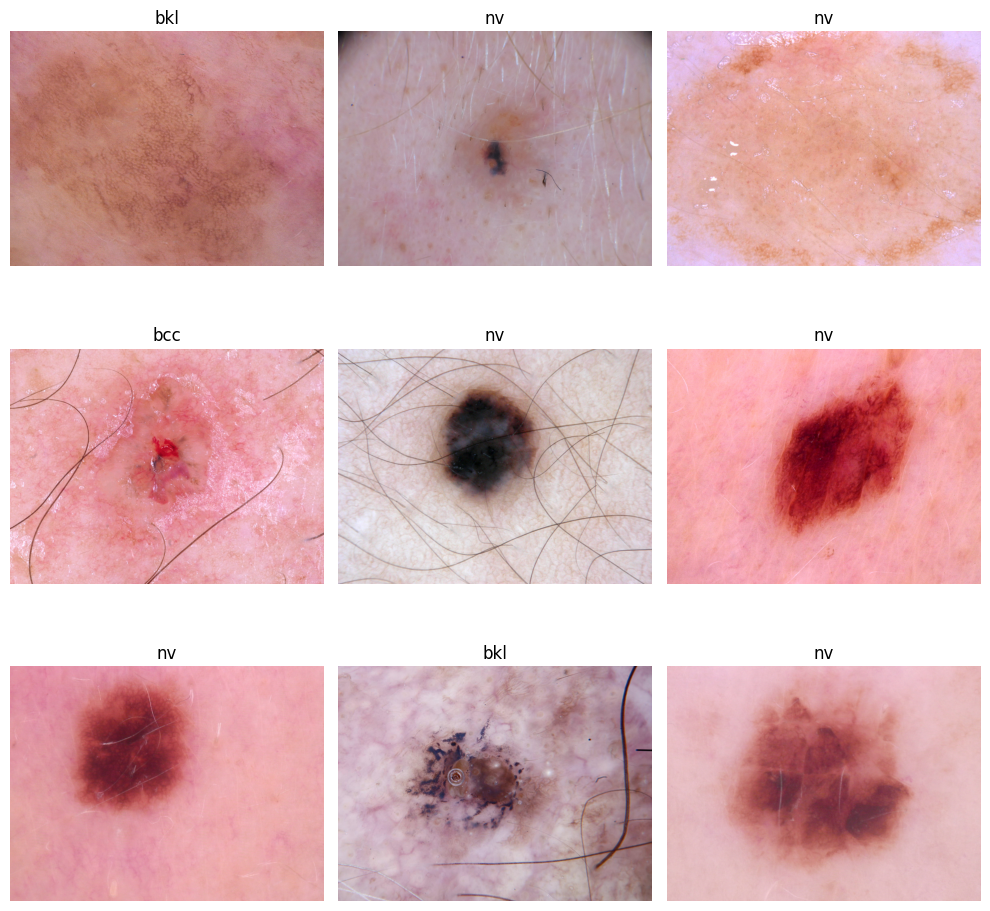

In [7]:
# =========================
# 05_train_real.ipynb — Célula 05
# Visual rápido: 9 imagens do treino (sanity)
# =========================

def show_grid(df_: pd.DataFrame, n: int = 9) -> None:
    n = min(n, len(df_))
    idxs = np.random.choice(len(df_), size=n, replace=False)
    cols = int(math.sqrt(n))
    rows = int(math.ceil(n / cols))

    plt.figure(figsize=(10, 10))
    for i, ix in enumerate(idxs, start=1):
        row = df_.iloc[ix]
        img_path = PROJECT_ROOT / str(row["image_path"])
        y = int(row["target_index"])
        img = Image.open(img_path).convert("RGB")

        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(index_to_label[y])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_grid(train_df, n=9)


In [8]:
# =========================
# 05_train_real.ipynb — Célula 06
# Dataset + transforms (augmentations úteis para dermatoscopia)
# =========================

import torchvision.transforms as T

IMG_SIZE = 224  # comece aqui; depois teste 300–384 para possível ganho (custo maior)

# Augmentations "mild": preserva estrutura da lesão (evita crops agressivos)
train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=180),
    T.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    T.RandomErasing(p=0.25, scale=(0.02, 0.10), ratio=(0.3, 3.3), value="random"),
])

eval_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

class LesionClsDataset(Dataset):
    def __init__(self, df: pd.DataFrame, project_root: Path, tfms: T.Compose):
        self.df = df.reset_index(drop=True)
        self.root = project_root
        self.tfms = tfms

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img_path = self.root / str(row["image_path"])
        y = int(row["target_index"])

        img = Image.open(img_path).convert("RGB")
        x = self.tfms(img)
        return x, y

train_ds = LesionClsDataset(train_df, PROJECT_ROOT, train_tfms)
val_ds   = LesionClsDataset(val_df, PROJECT_ROOT, eval_tfms)
test_ds  = LesionClsDataset(test_df, PROJECT_ROOT, eval_tfms)

print("OK — datasets:", len(train_ds), len(val_ds), len(test_ds))


OK — datasets: 7011 1502 1502


In [ ]:
# =========================
# 05_train_real.ipynb — Célula 07 (DATALOADER SAFE/TURBO)
# =========================

from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import random

# ---- Ajustes principais ----
BATCH_SIZE = 256  # tente 256 na 5080; se der OOM: 192 -> 128
SAFE_DATALOADER = True  # <<<<< comece True (anti-trava). Depois mude pra False (mais rápido)

if SAFE_DATALOADER:
    NUM_WORKERS = 0
    PREFETCH = None
    PERSISTENT = False
else:
    NUM_WORKERS = 4   # no Windows Notebook: 4 é mais estável que 8
    PREFETCH = 2
    PERSISTENT = False  # <<<<< no Windows/Jupyter eu recomendo False (evita deadlock)

# Contagens por classe (train)
train_counts = train_df["target_index"].value_counts().sort_index()
counts = np.array([train_counts.get(i, 0) for i in range(NUM_CLASSES)], dtype=np.float32)

total = counts.sum()
class_weights = total / (NUM_CLASSES * np.clip(counts, 1.0, None))
class_weights = class_weights / class_weights.mean()

print("counts:", {index_to_label[i]: int(counts[i]) for i in range(NUM_CLASSES)})
print("class_weights:", {index_to_label[i]: float(class_weights[i]) for i in range(NUM_CLASSES)})

# knobs imbalance
USE_CLASS_WEIGHTS = False
USE_WEIGHTED_SAMPLER = True  # deixe False por enquanto (sampler pode complicar debug)

sampler = None
if USE_WEIGHTED_SAMPLER:
    sample_w = class_weights[train_df["target_index"].values.astype(int)]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_w, dtype=torch.double),
        num_samples=len(sample_w),
        replacement=True,
    )

def seed_worker(worker_id: int) -> None:
    worker_seed = REPRO_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(REPRO_SEED)

common = dict(
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=PERSISTENT,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    generator=g,
)

if NUM_WORKERS > 0 and PREFETCH is not None:
    common["prefetch_factor"] = PREFETCH

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=(sampler is None),
    sampler=sampler,
    drop_last=True,
    **common,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **common,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **common,
)

print("OK — dataloaders.")
print("SAFE_DATALOADER:", SAFE_DATALOADER)
print("BATCH_SIZE:", BATCH_SIZE, "| NUM_WORKERS:", NUM_WORKERS)
print("batches train:", len(train_loader), "| val:", len(val_loader), "| test:", len(test_loader))


counts: {'mel': 779, 'nv': 4693, 'bcc': 360, 'akiec': 229, 'bkl': 769, 'df': 81, 'vasc': 100}
class_weights: {'mel': 0.27830880880355835, 'nv': 0.046197012066841125, 'bcc': 0.6022293567657471, 'akiec': 0.9467361569404602, 'bkl': 0.2819279432296753, 'df': 2.676574945449829, 'vasc': 2.1680257320404053}
OK — dataloaders.
SAFE_DATALOADER: True
BATCH_SIZE: 256 | NUM_WORKERS: 0
batches train: 27 | val: 6 | test: 6


In [ ]:
# =========================
# 05_train_real.ipynb — Célula 08 
# Modelo pré-treinado via torchvision (sem token HF) + loss + optimizer/scheduler
# =========================

import torchvision
import torchvision.models as tvm

MODEL_NAME = "resnet50"   # opções: "resnet50", "efficientnet_b0", "mobilenet_v3_large"
LR = 5e-4
WEIGHT_DECAY = 5e-5
EPOCHS = 18
LABEL_SMOOTHING = 0.05

LOSS_TYPE = "ce"     # "ce" ou "focal"
FOCAL_GAMMA = 1.5

def build_torchvision_model(name: str, num_classes: int) -> nn.Module:
    name = name.lower()

    if name == "resnet50":
        weights = tvm.ResNet50_Weights.DEFAULT
        m = tvm.resnet50(weights=weights)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m

    if name == "efficientnet_b0":
        weights = tvm.EfficientNet_B0_Weights.DEFAULT
        m = tvm.efficientnet_b0(weights=weights)
        # classifier: Sequential([Dropout, Linear])
        in_f = m.classifier[1].in_features
        m.classifier[1] = nn.Linear(in_f, num_classes)
        return m

    if name == "mobilenet_v3_large":
        weights = tvm.MobileNet_V3_Large_Weights.DEFAULT
        m = tvm.mobilenet_v3_large(weights=weights)
        in_f = m.classifier[3].in_features
        m.classifier[3] = nn.Linear(in_f, num_classes)
        return m

    raise ValueError(f"MODEL_NAME inválido: {name}. Use resnet50/efficientnet_b0/mobilenet_v3_large")

model = build_torchvision_model(MODEL_NAME, NUM_CLASSES).to(DEVICE)

w = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE) if USE_CLASS_WEIGHTS else None

class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, weight: Optional[torch.Tensor] = None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        logp = F.log_softmax(logits, dim=1)
        p = torch.exp(logp)
        pt = p.gather(1, target.view(-1, 1)).squeeze(1)
        logpt = logp.gather(1, target.view(-1, 1)).squeeze(1)
        loss = -((1.0 - pt) ** self.gamma) * logpt
        if self.weight is not None:
            loss = loss * self.weight[target]
        return loss.mean()

if LOSS_TYPE == "ce":
    criterion = nn.CrossEntropyLoss(weight=w, label_smoothing=LABEL_SMOOTHING)
elif LOSS_TYPE == "focal":
    criterion = FocalLoss(gamma=FOCAL_GAMMA, weight=w)
else:
    raise ValueError("LOSS_TYPE inválido. Use 'ce' ou 'focal'.")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

print("OK — torchvision model carregado:", MODEL_NAME)
print("torchvision:", torchvision.__version__)


OK — torchvision model carregado: mobilenet_v3_large
torchvision: 0.25.0.dev20260203+cu128


C:\Users\win\AppData\Local\Temp\ipykernel_15344\4052467796.py:74: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


In [11]:
# =========================
# 05_train_real.ipynb — Célula 09 (TQDM + DEBUG de travamento + GPU stats)
# =========================

from tqdm.auto import tqdm

def _gpu_mem_gb() -> float:
    if DEVICE.type != "cuda":
        return 0.0
    return torch.cuda.max_memory_allocated() / (1024**3)

@torch.no_grad()
def predict_logits(model: nn.Module, loader: DataLoader, desc: str = "val") -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_logits, all_y = [], []
    pbar = tqdm(loader, desc=desc, leave=False)
    for x, y in pbar:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        if DEVICE.type == "cuda":
            x = x.to(memory_format=torch.channels_last)
        logits = model(x)
        all_logits.append(logits.detach().cpu().numpy())
        all_y.append(y.detach().cpu().numpy())
    return np.concatenate(all_logits, axis=0), np.concatenate(all_y, axis=0)

def eval_metrics_from_logits(logits: np.ndarray, y_true: np.ndarray) -> Dict[str, float]:
    y_pred = logits.argmax(axis=1)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
    }

def train_one_epoch(model: nn.Module, loader: DataLoader, epoch: int, epochs: int) -> float:
    model.train()
    running = 0.0
    n = 0

    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    # ---- DEBUG: pega 1 batch antes pra provar que não travou no loader ----
    t_load0 = time.time()
    it = iter(loader)
    x0, y0 = next(it)   # <<<<< se travar, é AQUI (DataLoader)
    t_load1 = time.time()
    print(f"Epoch {epoch}: primeiro batch carregado em {t_load1 - t_load0:.2f}s")

    # recoloca esse primeiro batch na sequência do treino
    batches = [(x0, y0)]
    # e segue com o iterador normal
    batches_iter = list(batches)

    # vamos treinar: primeiro batch manual, depois tqdm no resto
    def _step_batch(x, y):
        nonlocal running, n
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        if DEVICE.type == "cuda":
            x = x.to(memory_format=torch.channels_last)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += float(loss.item()) * x.size(0)
        n += x.size(0)
        return float(loss.item())

    t0 = time.time()
    loss0 = _step_batch(x0, y0)

    pbar = tqdm(it, total=len(loader)-1, desc=f"train {epoch}/{epochs}", leave=False)
    for x, y in pbar:
        loss = _step_batch(x, y)
        avg_loss = running / max(n, 1)
        lr_now = optimizer.param_groups[0]["lr"]

        if DEVICE.type == "cuda":
            mem_gb = _gpu_mem_gb()
            pbar.set_postfix(loss=f"{avg_loss:.4f}", lr=f"{lr_now:.2e}", mem=f"{mem_gb:.2f}GB")
        else:
            pbar.set_postfix(loss=f"{avg_loss:.4f}", lr=f"{lr_now:.2e}")

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    dt = time.time() - t0
    sps = n / max(dt, 1e-9)
    print(f"Epoch {epoch}: train_loss={running/max(n,1):.4f} | {sps:.1f} samples/s | {dt/60:.2f} min | peak_mem={_gpu_mem_gb():.2f}GB")

    return running / max(n, 1)


In [12]:
# =========================
# 05_train_real.ipynb — Célula 10 (LOOP com DEBUG + ETA)
# =========================

def get_git_commit(project_root: Path) -> str:
    try:
        out = subprocess.check_output(["git", "-C", str(project_root), "rev-parse", "HEAD"], stderr=subprocess.DEVNULL)
        return out.decode("utf-8").strip()
    except Exception:
        return ""

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
EXP_NAME = f"cls_{MODEL_NAME}_img{IMG_SIZE}_seed{REPRO_SEED}_{RUN_ID}"

MODEL_DIR = PROJECT_ROOT / "models" / "05_train_real" / EXP_NAME
RUN_PLOTS_DIR = PLOTS_DIR / "05_train" / EXP_NAME
RUN_ART_DIR = PROCESSED_DIR / "05_runs" / EXP_NAME

for p in [MODEL_DIR, RUN_PLOTS_DIR, RUN_ART_DIR]:
    p.mkdir(parents=True, exist_ok=True)

best_f1 = -1.0
best_epoch = -1
patience = 3
no_improve = 0

history: List[Dict[str, float]] = []
epoch_times = []

print("=== START TRAIN LOOP ===")
print("EXP_NAME:", EXP_NAME)
print("git_commit:", get_git_commit(PROJECT_ROOT))
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    print(f"\n--- Epoch {epoch}/{EPOCHS} --- (iniciando treino)")
    t_epoch = time.time()

    tr_loss = train_one_epoch(model, train_loader, epoch, EPOCHS)
    scheduler.step()

    print(f"Epoch {epoch}: iniciando validação (predict_logits)")
    val_logits, val_y = predict_logits(model, val_loader, desc="val")
    val_metrics = eval_metrics_from_logits(val_logits, val_y)

    row = {
        "epoch": float(epoch),
        "train_loss": float(tr_loss),
        "val_accuracy": float(val_metrics["accuracy"]),
        "val_f1_macro": float(val_metrics["f1_macro"]),
        "lr": float(optimizer.param_groups[0]["lr"]),
    }
    history.append(row)

    dt_epoch = time.time() - t_epoch
    epoch_times.append(dt_epoch)
    avg_epoch = sum(epoch_times) / len(epoch_times)
    eta = (EPOCHS - epoch) * avg_epoch

    print(
        f"[{epoch:02d}/{EPOCHS}] "
        f"loss={tr_loss:.4f} | val_acc={row['val_accuracy']:.4f} | val_f1m={row['val_f1_macro']:.4f} | "
        f"lr={row['lr']:.2e} | epoch={dt_epoch/60:.2f} min | ETA={eta/60:.1f} min"
    )

    if row["val_f1_macro"] > best_f1 + 1e-6:
        best_f1 = row["val_f1_macro"]
        best_epoch = epoch
        no_improve = 0

        ckpt = {
            "model_name": MODEL_NAME,
            "img_size": IMG_SIZE,
            "num_classes": NUM_CLASSES,
            "index_to_label": index_to_label,
            "state_dict": model.state_dict(),
            "epoch": int(epoch),
            "val_f1_macro": float(best_f1),
            "seed": int(REPRO_SEED),
        }
        torch.save(ckpt, MODEL_DIR / "best.pt")
        print(f"Checkpoint salvo: best.pt (epoch={epoch}, f1m={best_f1:.4f})")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping: sem melhora em {patience} épocas. Best epoch={best_epoch} best_f1={best_f1:.4f}")
            break

elapsed = time.time() - t0
print("\nTreino finalizado. elapsed(min):", round(elapsed/60, 2))
print("BEST:", best_epoch, best_f1)

print("Salvando train_history.csv ...")
hist_df = pd.DataFrame(history)
hist_df.to_csv(RUN_ART_DIR / "train_history.csv", index=False, encoding="utf-8")
print("OK — train_history.csv salvo.")


=== START TRAIN LOOP ===
EXP_NAME: cls_mobilenet_v3_large_img224_seed42_20260205_163515
git_commit: 02f2faacdbefc41be13ef27fc55cc986aae966f5
DEVICE: cuda
GPU: NVIDIA GeForce RTX 5080

--- Epoch 1/18 --- (iniciando treino)
Epoch 1: primeiro batch carregado em 1.43s


C:\Users\win\AppData\Local\Temp\ipykernel_15344\1243946032.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


train 1/18:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 1: train_loss=0.2177 | 77.7 samples/s | 1.48 min | peak_mem=5.56GB
Epoch 1: iniciando validação (predict_logits)


val:   0%|          | 0/6 [00:00<?, ?it/s]

...

C:\Users\win\AppData\Local\Temp\ipykernel_15344\1243946032.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


train 14/18:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 14: train_loss=0.0177 | 121.2 samples/s | 0.95 min | peak_mem=5.54GB
Epoch 14: iniciando validação (predict_logits)


val:   0%|          | 0/6 [00:00<?, ?it/s]

[14/18] loss=0.0177 | val_acc=0.8415 | val_f1m=0.7793 | lr=3.51e-05 | epoch=1.07 min | ETA=4.7 min
Early stopping: sem melhora em 3 épocas. Best epoch=11 best_f1=0.8006

Treino finalizado. elapsed(min): 16.52
BEST: 11 0.8005754245369345
Salvando train_history.csv ...
OK — train_history.csv salvo.


In [13]:
# =========================
# 05_train_real.ipynb — Célula 11
# Plots: loss e métricas por época (salvar)
# =========================

def plot_curve(x, y, title, xlabel, ylabel, save_path: Path) -> None:
    plt.figure(figsize=(7, 4))
    plt.plot(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=160)
    plt.close()

epochs = hist_df["epoch"].values
plot_curve(epochs, hist_df["train_loss"].values, "Train Loss", "epoch", "loss", RUN_PLOTS_DIR / "curve_train_loss.png")
plot_curve(epochs, hist_df["val_accuracy"].values, "Val Accuracy", "epoch", "accuracy", RUN_PLOTS_DIR / "curve_val_accuracy.png")
plot_curve(epochs, hist_df["val_f1_macro"].values, "Val Macro-F1", "epoch", "f1_macro", RUN_PLOTS_DIR / "curve_val_f1_macro.png")

print("OK — curvas salvas em:", RUN_PLOTS_DIR)


OK — curvas salvas em: C:\Users\win\Documents\GitHub\pimple\reports\plots\05_train\cls_mobilenet_v3_large_img224_seed42_20260205_163515


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List

def plot_confusion(cm: np.ndarray, class_names: List[str], title: str, save_path: Path, normalize: bool = False) -> None:
    cm_plot = cm.astype(np.float32)
    if normalize:
        cm_plot = cm_plot / np.clip(cm_plot.sum(axis=1, keepdims=True), 1e-9, None)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm_plot)
    plt.title(title)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(range(len(class_names)), class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm_plot[i, j]
            s = f"{val:.2f}" if normalize else f"{int(cm[i,j])}"
            plt.text(j, i, s, ha="center", va="center", fontsize=8)

    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=160)
    plt.close()


In [15]:
# =========================
# 05_train_real.ipynb — Célula 12
# Avaliar BEST em val/test + salvar logits/labels para Notebook 06
# =========================

best_path = MODEL_DIR / "best.pt"
assert best_path.exists(), f"Checkpoint não encontrado: {best_path}"

ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt["state_dict"])
model.eval()

# VAL
val_logits, val_y = predict_logits(model, val_loader)
val_pred = val_logits.argmax(axis=1)
val_metrics = eval_metrics_from_logits(val_logits, val_y)
val_cm = confusion_matrix(val_y, val_pred, labels=list(range(NUM_CLASSES)))

print("VAL metrics:", val_metrics)

plot_confusion(
    val_cm,
    class_names=index_to_label,
    title=f"VAL Confusion (best epoch={ckpt['epoch']} f1m={ckpt['val_f1_macro']:.3f})",
    save_path=RUN_PLOTS_DIR / "cm_val.png",
    normalize=False,
)
plot_confusion(
    val_cm,
    class_names=index_to_label,
    title="VAL Confusion (normalized)",
    save_path=RUN_PLOTS_DIR / "cm_val_norm.png",
    normalize=True,
)

# TEST
test_logits, test_y = predict_logits(model, test_loader)
test_pred = test_logits.argmax(axis=1)
test_metrics = eval_metrics_from_logits(test_logits, test_y)
test_cm = confusion_matrix(test_y, test_pred, labels=list(range(NUM_CLASSES)))

print("TEST metrics:", test_metrics)

plot_confusion(
    test_cm,
    class_names=index_to_label,
    title="TEST Confusion",
    save_path=RUN_PLOTS_DIR / "cm_test.png",
    normalize=False,
)
plot_confusion(
    test_cm,
    class_names=index_to_label,
    title="TEST Confusion (normalized)",
    save_path=RUN_PLOTS_DIR / "cm_test_norm.png",
    normalize=True,
)

# Salvar logits/labels (calibração)
np.save(RUN_ART_DIR / "val_logits.npy", val_logits)
np.save(RUN_ART_DIR / "val_labels.npy", val_y)
np.save(RUN_ART_DIR / "test_logits.npy", test_logits)
np.save(RUN_ART_DIR / "test_labels.npy", test_y)

print("OK — logits/labels salvos em:", RUN_ART_DIR)


val:   0%|          | 0/6 [00:00<?, ?it/s]

VAL metrics: {'accuracy': 0.8382157123834887, 'f1_macro': 0.8005754245369345}


val:   0%|          | 0/6 [00:00<?, ?it/s]

TEST metrics: {'accuracy': 0.8268974700399467, 'f1_macro': 0.7414932277239534}
OK — logits/labels salvos em: C:\Users\win\Documents\GitHub\pimple\data\processed\05_runs\cls_mobilenet_v3_large_img224_seed42_20260205_163515


In [16]:
# =========================
# 05_train_real.ipynb — Célula 13
# Classification report + export config + summary reprodutível
# =========================

# Reports em texto
report_val = classification_report(val_y, val_pred, target_names=index_to_label, digits=4)
report_test = classification_report(test_y, test_pred, target_names=index_to_label, digits=4)

(RUN_ART_DIR / "classification_report_val.txt").write_text(report_val, encoding="utf-8")
(RUN_ART_DIR / "classification_report_test.txt").write_text(report_test, encoding="utf-8")

# Config do treino
train_config = {
    "exp_name": EXP_NAME,
    "run_id": RUN_ID,
    "seed": int(REPRO_SEED),
    "git_commit": get_git_commit(PROJECT_ROOT),
    "model_name": MODEL_NAME,
    "img_size": int(IMG_SIZE),
    "num_classes": int(NUM_CLASSES),
    "classes": index_to_label,
    "batch_size": int(BATCH_SIZE),
    "epochs_requested": int(EPOCHS),
    "epochs_ran": int(hist_df["epoch"].max()),
    "best_epoch": int(ckpt["epoch"]),
    "best_val_f1_macro": float(ckpt["val_f1_macro"]),
    "loss_type": LOSS_TYPE,
    "focal_gamma": float(FOCAL_GAMMA),
    "label_smoothing": float(LABEL_SMOOTHING),
    "use_class_weights": bool(USE_CLASS_WEIGHTS),
    "use_weighted_sampler": bool(USE_WEIGHTED_SAMPLER),
    "lr": float(LR),
    "weight_decay": float(WEIGHT_DECAY),
    "scheduler": "CosineAnnealingLR",
    "inputs": {
        "train_csv": str(TRAIN_CSV.relative_to(PROJECT_ROOT)),
        "val_csv": str(VAL_CSV.relative_to(PROJECT_ROOT)),
        "test_csv": str(TEST_CSV.relative_to(PROJECT_ROOT)),
        "label_map": str(LABEL_MAP_PATH.relative_to(PROJECT_ROOT)),
        "target_config": str(TARGET_CFG_PATH.relative_to(PROJECT_ROOT)) if TARGET_CFG_PATH.exists() else "",
    },
    "outputs": {
        "model_dir": str(MODEL_DIR.relative_to(PROJECT_ROOT)),
        "run_art_dir": str(RUN_ART_DIR.relative_to(PROJECT_ROOT)),
        "plots_dir": str(RUN_PLOTS_DIR.relative_to(PROJECT_ROOT)),
    },
}

(RUN_ART_DIR / "train_config.json").write_text(json.dumps(train_config, indent=2, ensure_ascii=False), encoding="utf-8")

# Summary de métricas
summary = {
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "val": val_metrics,
    "test": test_metrics,
}

(RUN_ART_DIR / "metrics_summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

print("=== OK — Artefatos finais ===")
print("EXP_NAME   :", EXP_NAME)
print("MODEL_DIR  :", MODEL_DIR)
print("RUN_ART_DIR:", RUN_ART_DIR)
print("PLOTS_DIR  :", RUN_PLOTS_DIR)
print("\n>>> Use este EXP_NAME no Notebook 06 (calibração):", EXP_NAME)


=== OK — Artefatos finais ===
EXP_NAME   : cls_mobilenet_v3_large_img224_seed42_20260205_163515
MODEL_DIR  : C:\Users\win\Documents\GitHub\pimple\models\05_train_real\cls_mobilenet_v3_large_img224_seed42_20260205_163515
RUN_ART_DIR: C:\Users\win\Documents\GitHub\pimple\data\processed\05_runs\cls_mobilenet_v3_large_img224_seed42_20260205_163515
PLOTS_DIR  : C:\Users\win\Documents\GitHub\pimple\reports\plots\05_train\cls_mobilenet_v3_large_img224_seed42_20260205_163515

>>> Use este EXP_NAME no Notebook 06 (calibração): cls_mobilenet_v3_large_img224_seed42_20260205_163515
